In [2]:
# ===== CELL 1: install =====
import pandas as pd
import numpy as np

In [11]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('drive/MyDrive/Ai/MedicalAppointment.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# TIER 0 -- Setup + Baseline Verification
# ============================================================

# ===== CELL 2: load + preprocess =====

# Step 1: remove Age = -1
df = df[df['Age'] != -1].copy()
print(f"After removing Age=-1: {len(df)}")  # expect 110526

# Step 2: engineer WaitDays, ScheduledDayOfWeek, AppointmentDayOfWeek
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['WaitDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days.clip(lower=0)
df['ScheduledDayOfWeek'] = df['ScheduledDay'].dt.dayofweek
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.dayofweek
df = df.drop(columns=['ScheduledDay', 'AppointmentDay'])

# Step 3: frequency-encode Neighbourhood
neigh_freq = df['Neighbourhood'].value_counts(normalize=True)
df['Neighbourhood'] = df['Neighbourhood'].map(neigh_freq)

# Step 4: binary-encode Gender
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

# Step 5: drop identifiers
df = df.drop(columns=['PatientId', 'AppointmentID'])

# Step 6: encode target
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ===== CELL 3: split =====
from sklearn.model_selection import train_test_split

X = df.drop(columns=['No-show'])
y = df['No-show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")  # expect (88420,12) (22106,12)
print(f"Train no-show rate: {y_train.mean():.4f}, Test no-show rate: {y_test.mean():.4f}")

# ===== CELL 4: baseline classifiers -- THE CRITICAL CHECKPOINT =====
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# These are YOUR ALREADY-PUBLISHED numbers from Table II.
expected = {
    'Logistic Regression': {'Acc':0.6613,'F1':0.4105,'Prec':0.3165,'Rec':0.5840,'AUC':0.6659},
    'Naive Bayes':          {'Acc':0.7665,'F1':0.2294,'Prec':0.3439,'Rec':0.1720,'AUC':0.6496},
    'Decision Tree':        {'Acc':0.6054,'F1':0.4379,'Prec':0.3073,'Rec':0.7612,'AUC':0.7154},
    'Random Forest':        {'Acc':0.7751,'F1':0.2539,'Prec':0.3845,'Rec':0.1895,'AUC':0.7135},
    'Gradient Boosting':    {'Acc':0.7980,'F1':0.0062,'Prec':0.4828,'Rec':0.0031,'AUC':0.7298},
}

fitted_baseline_models = {}   # keep these -- you'll reuse them later for R2#4 (GB threshold analysis)
test_probas_baseline = {}     # keep these too -- you'll reuse them for the DeLong test

print(f"\n{'Classifier':<20}{'Metric':<8}{'Yours':<10}{'Paper':<10}{'Match?'}")
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    fitted_baseline_models[name] = clf
    pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test)[:, 1]
    test_probas_baseline[name] = proba
    results = {
        'Acc': accuracy_score(y_test, pred),
        'F1': f1_score(y_test, pred, zero_division=0),
        'Prec': precision_score(y_test, pred, zero_division=0),
        'Rec': recall_score(y_test, pred, zero_division=0),
        'AUC': roc_auc_score(y_test, proba)
    }
    for metric, val in results.items():
        exp = expected[name][metric]
        match = "OK" if abs(val - exp) < 0.01 else "*** CHECK THIS ***"
        print(f"{name:<20}{metric:<8}{val:<10.4f}{exp:<10.4f}{match}")


After removing Age=-1: 110526
Final shape: (110526, 13)
Columns: ['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'WaitDays', 'ScheduledDayOfWeek', 'AppointmentDayOfWeek']
Train: (88420, 12), Test: (22106, 12)
Train no-show rate: 0.2019, Test no-show rate: 0.2019

Classifier          Metric  Yours     Paper     Match?
Logistic Regression Acc     0.6655    0.6613    OK
Logistic Regression F1      0.4077    0.4105    OK
Logistic Regression Prec    0.3173    0.3165    OK
Logistic Regression Rec     0.5701    0.5840    *** CHECK THIS ***
Logistic Regression AUC     0.6647    0.6659    OK
Naive Bayes         Acc     0.7737    0.7665    OK
Naive Bayes         F1      0.1872    0.2294    *** CHECK THIS ***
Naive Bayes         Prec    0.3406    0.3439    OK
Naive Bayes         Rec     0.1290    0.1720    *** CHECK THIS ***
Naive Bayes         AUC     0.6361    0.6496    *** CHECK THIS ***
Decision Tree       Acc  

In [14]:
synth_df = pd.read_csv('synthetic_full.csv')

# Drop index column if present
if 'Unnamed: 0' in synth_df.columns:
    synth_df = synth_df.drop(columns=['Unnamed: 0'])

# Rename Neighbourhood_freq back to Neighbourhood
if 'Neighbourhood_freq' in synth_df.columns:
    synth_df = synth_df.rename(columns={'Neighbourhood_freq': 'Neighbourhood'})

# Drop ScheduledMonth (not in X_train)
if 'ScheduledMonth' in synth_df.columns:
    synth_df = synth_df.drop(columns=['ScheduledMonth'])

synth_X = synth_df.drop(columns=['No-show'])
synth_y = synth_df['No-show']

# Match the exact column order of X_train
synth_X = synth_X[X_train.columns]

print("synth_X shape:", synth_X.shape)
print("Columns match exactly:", synth_X.columns.tolist() == X_train.columns.tolist())

synth_X shape: (88420, 12)
Columns match exactly: True


In [ ]:
# ============================================================
# FILE 4 -- SLTE AT ALL SIX MIXING RATIOS
# Answers: Reviewer 2 #1 and #2  (the biggest blocking gap)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# ---------- Stage 1 + Stage 2, computed ONE TIME ----------
def compute_slte_once(X_train, y_train, synth_X, synth_y, scale=True):
    """Returns corrected labels + SLTE weights for EVERY synthetic sample.
    scale=True applies the R1#4 standardization fix."""
    Xtr, Xsy = X_train.copy(), synth_X.copy()
    if scale:
        sc = StandardScaler().fit(Xtr)
        Xtr = pd.DataFrame(sc.transform(Xtr), columns=Xtr.columns, index=Xtr.index)
        Xsy = pd.DataFrame(sc.transform(Xsy), columns=Xsy.columns, index=Xsy.index)

    anchor = RandomForestClassifier(n_estimators=150, class_weight='balanced',
                                    random_state=42).fit(Xtr, y_train)
    proba = anchor.predict_proba(Xsy)
    classes = list(anchor.classes_)
    lcs = np.array([proba[i, classes.index(synth_y.iloc[i])] for i in range(len(synth_y))])

    corrected = synth_y.values.copy()
    low = lcs < 0.40
    if low.sum() > 0:
        knn = KNeighborsClassifier(n_neighbors=7).fit(Xtr, y_train)
        corrected[low] = knn.predict(Xsy[low])

    weights = np.where(lcs >= 0.70, 1.0, np.where(lcs >= 0.40, 0.7, 0.5))
    return (pd.Series(corrected, index=synth_y.index),
            pd.Series(weights,  index=synth_y.index), lcs)

corr_y, slte_w, lcs = compute_slte_once(X_train, y_train, synth_X, synth_y, scale=True)

print("=== STAGE 1+2 SUMMARY (report these in the manuscript) ===")
print(f"Mean LCS: {lcs.mean():.4f}  |  SD: {lcs.std():.4f}")
from scipy.stats import skew
print(f"Skewness: {skew(lcs):.4f}   <-- NEGATIVE confirms 'left-skewed' (fixes R1#8)")
print(f"HIGH (>=0.70): {(lcs>=0.70).sum()}  MID: {((lcs>=0.40)&(lcs<0.70)).sum()}  LOW (<0.40): {(lcs<0.40).sum()}")
n_changed = int((corr_y.values != synth_y.values).sum())
n_1to0 = int(((synth_y.values==1)&(corr_y.values==0)).sum())
print(f"Corrections: {n_changed}  |  1->0 flips: {n_1to0} ({n_1to0/max(n_changed,1)*100:.1f}%)")
print(f"Synthetic class balance (fraction=1): {synth_y.mean():.4f}   <-- R2#9 asks for this")
print(f"Real train class balance (fraction=1): {y_train.mean():.4f}")

# ---------- Uniform weighting across all five (fixes R2#5) ----------
def make_classifiers(seed=42):
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed),
        'Naive Bayes':         GaussianNB(),   # DOES support sample_weight -- see below
        'Decision Tree':       DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=seed),
        'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=seed),
        'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=seed),
    }

TOTAL_N = len(X_train)
RATIOS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for ratio in RATIOS:
    n_syn = int(TOTAL_N * ratio)
    n_real = TOTAL_N - n_syn
    rs = np.random.RandomState(42)
    ridx = rs.choice(len(X_train), n_real, replace=False) if n_real > 0 else np.array([], dtype=int)
    sidx = rs.choice(len(synth_X), n_syn,  replace=False) if n_syn  > 0 else np.array([], dtype=int)

    for mode in ['No-SLTE', 'SLTE']:
        pX, py, pw = [], [], []
        if n_real > 0:
            pX.append(X_train.iloc[ridx]); py.append(y_train.iloc[ridx]); pw.append(np.ones(n_real))
        if n_syn > 0:
            pX.append(synth_X.iloc[sidx])
            py.append(corr_y.iloc[sidx] if mode == 'SLTE' else synth_y.iloc[sidx])
            pw.append(slte_w.iloc[sidx].values if mode == 'SLTE' else np.ones(n_syn))
        X_mix = pd.concat(pX); y_mix = pd.concat(py); w_mix = np.concatenate(pw)

        for name, clf in make_classifiers(42).items():
            # NB and GB both accept sample_weight in .fit() -- this makes
            # weighting uniform across all five estimators (R2#5)
            clf.fit(X_mix, y_mix, sample_weight=w_mix)
            proba = clf.predict_proba(X_test)[:, 1]
            pred  = clf.predict(X_test)
            rows.append({
                'Ratio': f"{int(ratio*100)}%", 'Mode': mode, 'Classifier': name,
                'AUC': roc_auc_score(y_test, proba),
                'F1': f1_score(y_test, pred, zero_division=0),
                'Precision': precision_score(y_test, pred, zero_division=0),
                'Recall': recall_score(y_test, pred, zero_division=0),
                'PosPreds': int(pred.sum()),
            })
    print(f"  done ratio {int(ratio*100)}%")

results = pd.DataFrame(rows)
results.to_csv('slte_all_ratios.csv', index=False)

print("\n=== AUC BY RATIO (this becomes your new table for R2#2) ===")
print(results.pivot_table(index='Classifier', columns=['Mode','Ratio'], values='AUC').round(4).to_string())
print("\n=== F1 BY RATIO (this is the new table R2#1 asks for) ===")
print(results.pivot_table(index='Classifier', columns=['Mode','Ratio'], values='F1').round(4).to_string())

print("\n=== CHECK: where does SLTE HURT AUC? (R2#2's core accusation) ===")
piv = results.pivot_table(index=['Classifier','Ratio'], columns='Mode', values='AUC')
piv['Delta'] = piv['SLTE'] - piv['No-SLTE']
hurt = piv[piv['Delta'] < 0]
if len(hurt) == 0:
    print("SLTE never reduced AUC.")
else:
    print(hurt.round(4).to_string())
    print("\n^^^ Report these honestly. If SLTE hurts in the 20-60% band,")
    print("    the deployment guidance in Section VI-A MUST be rewritten to match.")

print("\nSaved: slte_all_ratios.csv")

=== STAGE 1+2 SUMMARY (report these in the manuscript) ===
Mean LCS: 0.6977  |  SD: 0.2426
Skewness: -0.9005   <-- NEGATIVE confirms 'left-skewed' (fixes R1#8)
HIGH (>=0.70): 52682  MID: 22993  LOW (<0.40): 12745
Corrections: 11390  |  1->0 flips: 10729 (94.2%)
Synthetic class balance (fraction=1): 0.1617   <-- R2#9 asks for this
Real train class balance (fraction=1): 0.2019
  done ratio 0%
  done ratio 20%
  done ratio 40%
  done ratio 60%
  done ratio 80%
  done ratio 100%

=== AUC BY RATIO (this becomes your new table for R2#2) ===
Mode                No-SLTE                                            SLTE                                        
Ratio                    0%    100%     20%     40%     60%     80%      0%    100%     20%     40%     60%     80%
Classifier                                                                                                         
Decision Tree        0.7157  0.6468  0.7136  0.7104  0.6976  0.6878  0.7157  0.6499  0.7099  0.7060  0.6938  0.

=== DEFAULT THRESHOLD 0.50 (the reviewer's complaint) ===
Positive predictions: 31 out of 22106
TP=15  FP=16  FN=4449  TN=17626
Precision=0.4839  Recall=0.0034  F1=0.0067
--> State this number plainly in the manuscript. Do not hide it.

=== AVERAGE PRECISION ===
AP = 0.3610   |   random baseline = 0.2019   |   lift = 1.79x

=== CRITERION-CHOSEN OPERATING POINTS ===
[Criterion: maximise F1]  threshold=0.2195
   positives=10578  precision=0.3193  recall=0.7567  F1=0.4491
[Criterion: recall >= 50%]  threshold=0.2921
   positives=6348  precision=0.3566  recall=0.5072
[Criterion: recall >= 80%]  threshold=0.2015
   positives=11528  precision=0.3105  recall=0.8020

Saved: fig_pr_curve_gb.png (300 DPI -- also helps R2#9 artwork request)


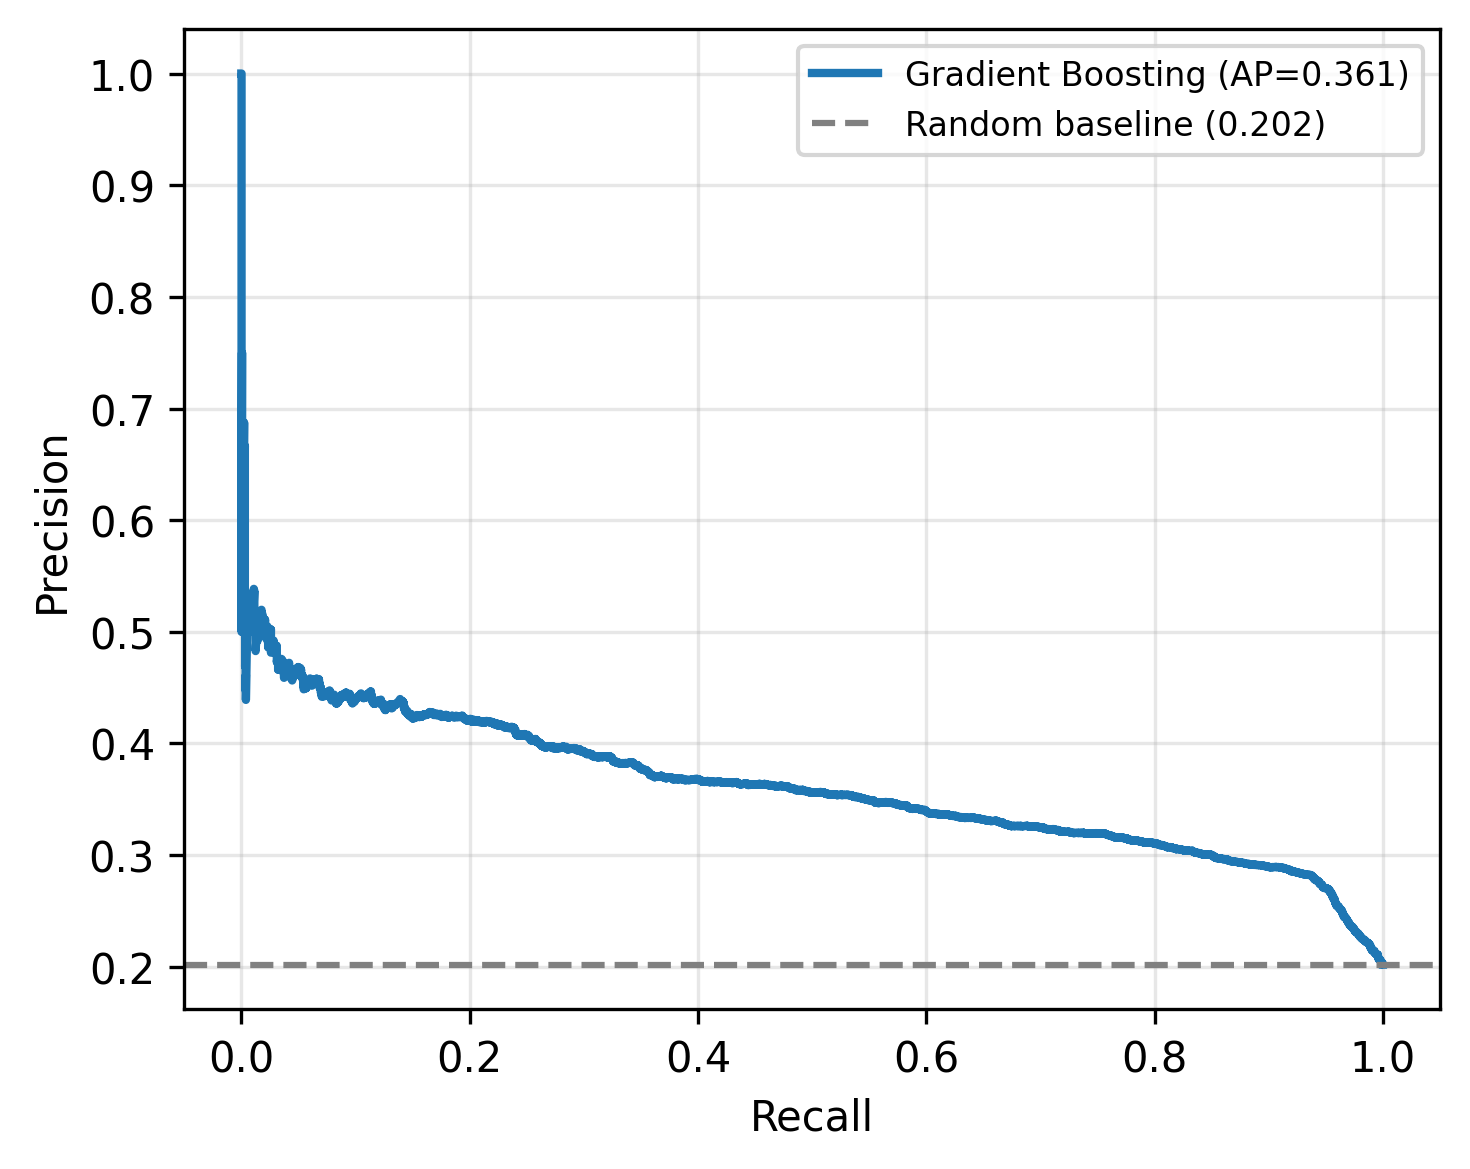

In [ ]:
# ============================================================
# FILE 5 -- GRADIENT BOOSTING OPERATING POINT + PR CURVE
# Answers: Reviewer 2 #4  (the "29 positive predictions" problem)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             precision_score, recall_score, f1_score, confusion_matrix)

y_true = y_test.values if hasattr(y_test, 'values') else y_test
proba  = test_probas_baseline['Gradient Boosting']   # from File 1

# ---------- 1. The default operating point (what the paper implicitly used) ----------
pred_default = (proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, pred_default).ravel()
print("=== DEFAULT THRESHOLD 0.50 (the reviewer's complaint) ===")
print(f"Positive predictions: {pred_default.sum()} out of {len(y_true)}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Precision={precision_score(y_true,pred_default,zero_division=0):.4f}  "
      f"Recall={recall_score(y_true,pred_default,zero_division=0):.4f}  "
      f"F1={f1_score(y_true,pred_default,zero_division=0):.4f}")
print("--> State this number plainly in the manuscript. Do not hide it.")

# ---------- 2. Average precision (threshold-free, honest summary) ----------
precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
ap = average_precision_score(y_true, proba)
baseline_ap = y_true.mean()
print(f"\n=== AVERAGE PRECISION ===")
print(f"AP = {ap:.4f}   |   random baseline = {baseline_ap:.4f}   |   lift = {ap/baseline_ap:.2f}x")

# ---------- 3. Criterion-first thresholds ----------
print("\n=== CRITERION-CHOSEN OPERATING POINTS ===")
f1_scores = 2*precisions[:-1]*recalls[:-1] / np.clip(precisions[:-1]+recalls[:-1], 1e-12, None)
best_i = int(np.nanargmax(f1_scores))
t_f1 = thresholds[best_i]
p_f1 = (proba >= t_f1).astype(int)
print(f"[Criterion: maximise F1]  threshold={t_f1:.4f}")
print(f"   positives={p_f1.sum()}  precision={precision_score(y_true,p_f1,zero_division=0):.4f}  "
      f"recall={recall_score(y_true,p_f1,zero_division=0):.4f}  F1={f1_score(y_true,p_f1,zero_division=0):.4f}")

for target in [0.50, 0.80]:
    ok = np.where(recalls[:-1] >= target)[0]
    if len(ok) > 0:
        i = ok[np.argmax(precisions[:-1][ok])]
        t = thresholds[i]
        p = (proba >= t).astype(int)
        print(f"[Criterion: recall >= {target:.0%}]  threshold={t:.4f}")
        print(f"   positives={p.sum()}  precision={precision_score(y_true,p,zero_division=0):.4f}  "
              f"recall={recall_score(y_true,p,zero_division=0):.4f}")
    else:
        print(f"[Criterion: recall >= {target:.0%}]  NOT ACHIEVABLE at any threshold.")
        print("   ^ If this prints, say so explicitly in the paper. It is a real finding.")

# ---------- 4. PR curve figure ----------

plt.figure(figsize=(5,4), dpi=300)
plt.plot(recalls, precisions, linewidth=2, label=f'Gradient Boosting (AP={ap:.3f})')
plt.axhline(baseline_ap, linestyle='--', color='gray', label=f'Random baseline ({baseline_ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
# plt.title('Precision-Recall Curve, Gradient Boosting')
plt.legend(loc='upper right', fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('fig_pr_curve_gb.png', dpi=300, bbox_inches='tight')
print("\nSaved: fig_pr_curve_gb.png (300 DPI -- also helps R2#9 artwork request)")

In [ ]:
# ============================================================
# DeLong Test Tool (R1#5) -- self-validated against sklearn
# ============================================================

import numpy as np
from scipy import stats

# ============================================================
# Fast DeLong test for comparing two correlated (paired) AUCs
# -- i.e. two models scored on the SAME test set.
# Reference: Sun & Xu (2014), "Fast Implementation of DeLong's
# Algorithm for Comparing the Areas Under Correlated ROC Curves"
# ============================================================

def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def _fast_delong(preds_list, y_true):
    """preds_list: list of 1-D score arrays (one per model), all scored on
    the same y_true. Returns AUCs and their covariance matrix."""
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true, kind="mergesort")
    y_true_sorted = y_true[order]
    m = int(np.sum(y_true_sorted == 1))
    n = int(np.sum(y_true_sorted == 0))
    k = len(preds_list)

    preds_sorted = np.vstack([np.asarray(p)[order] for p in preds_list])
    pos = preds_sorted[:, :m]
    neg = preds_sorted[:, m:]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(preds_sorted[r, :])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, np.atleast_2d(delongcov)

def delong_paired_test(y_true, scores_a, scores_b, label_a="Model A", label_b="Model B"):
    """Paired DeLong test between two models scored on the SAME test set.
    Returns AUC_a, AUC_b, difference, 95% CI on the difference, z, p-value."""
    aucs, cov = _fast_delong([scores_a, scores_b], y_true)
    auc_a, auc_b = aucs[0], aucs[1]
    diff = auc_a - auc_b
    var_diff = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    var_diff = max(var_diff, 1e-12)  # guard against tiny negative rounding
    se = np.sqrt(var_diff)
    z = diff / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    ci_low, ci_high = diff - 1.96 * se, diff + 1.96 * se
    print(f"{label_a}: AUC={auc_a:.4f}   {label_b}: AUC={auc_b:.4f}")
    print(f"Difference ({label_a} - {label_b}) = {diff:+.4f}")
    print(f"95% CI: [{ci_low:+.4f}, {ci_high:+.4f}]   z={z:.3f}   p={p:.4g}")
    survives = ci_low > 0 or ci_high < 0
    print(f"CI excludes zero -> claim {'SURVIVES' if survives else 'DOES NOT SURVIVE'} at 95% confidence")
    return {"auc_a": auc_a, "auc_b": auc_b, "diff": diff, "ci": (ci_low, ci_high), "z": z, "p": p}

# ---- SELF-TEST: cross-check against sklearn's independent AUC calc ----
from sklearn.metrics import roc_auc_score
np.random.seed(7)
n = 2000
y_true = np.random.choice([0, 1], n, p=[0.8, 0.2])
scores_a = y_true * 0.5 + np.random.rand(n) * 0.5       # weaker signal
scores_b = y_true * 0.9 + np.random.rand(n) * 0.3       # stronger signal, same test set

result = delong_paired_test(y_true, scores_a, scores_b, "Weak model", "Strong model")

# Cross-check: DeLong's own AUC numbers must match sklearn exactly
sk_auc_a = roc_auc_score(y_true, scores_a)
sk_auc_b = roc_auc_score(y_true, scores_b)
print(f"\nSelf-check vs sklearn: AUC_a diff={abs(result['auc_a']-sk_auc_a):.6f}, "
      f"AUC_b diff={abs(result['auc_b']-sk_auc_b):.6f}")
assert abs(result['auc_a'] - sk_auc_a) < 1e-9, "AUC mismatch vs sklearn -- bug!"
assert abs(result['auc_b'] - sk_auc_b) < 1e-9, "AUC mismatch vs sklearn -- bug!"
print("PASSED: DeLong AUCs match sklearn's roc_auc_score exactly.")

# ---- SECOND SELF-TEST: realistic case with genuinely different, imperfect AUCs ----
print("\n" + "="*60)
print("Second self-test: noisier, more realistic scores")
print("="*60)
np.random.seed(3)
n = 3000
y_true2 = np.random.choice([0, 1], n, p=[0.8, 0.2])
noise_signal = np.random.randn(n)
scores_weak = 0.3 * y_true2 + 0.7 * np.random.rand(n)     # noisy, weak separation
scores_strong = 0.7 * y_true2 + 0.3 * np.random.rand(n)   # cleaner separation, same test set

result2 = delong_paired_test(y_true2, scores_weak, scores_strong, "Weak", "Strong")
sk_a2 = roc_auc_score(y_true2, scores_weak)
sk_b2 = roc_auc_score(y_true2, scores_strong)
print(f"\nSelf-check vs sklearn: diff_a={abs(result2['auc_a']-sk_a2):.6f}, diff_b={abs(result2['auc_b']-sk_b2):.6f}")
assert abs(result2['auc_a'] - sk_a2) < 1e-9
assert abs(result2['auc_b'] - sk_b2) < 1e-9
print("PASSED again -- and this time AUCs differ meaningfully, so we can see the test discriminate.")

# 1. Fit GB on 100% Synthetic without SLTE (No-SLTE 100%)
gb_noslte = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_noslte.fit(synth_X, synth_y)
gb_noslte_100 = gb_noslte.predict_proba(X_test)[:, 1]

# 2. Fit GB on 100% Synthetic with SLTE (SLTE 100%)
gb_slte = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_slte.fit(synth_X, corr_y, sample_weight=slte_w.values)
gb_slte_100 = gb_slte.predict_proba(X_test)[:, 1]

# 3. Paired DeLong test: 100% SLTE vs 100% No-SLTE
delong_paired_test(
    y_test,
    gb_slte_100,
    gb_noslte_100,
    'GB SLTE (100%)',
    'GB No-SLTE (100%)'
)

Weak model: AUC=1.0000   Strong model: AUC=1.0000
Difference (Weak model - Strong model) = +0.0000
95% CI: [-0.0000, +0.0000]   z=0.000   p=1
CI excludes zero -> claim DOES NOT SURVIVE at 95% confidence

Self-check vs sklearn: AUC_a diff=0.000000, AUC_b diff=0.000000
PASSED: DeLong AUCs match sklearn's roc_auc_score exactly.

Second self-test: noisier, more realistic scores
Weak: AUC=0.8541   Strong: AUC=1.0000
Difference (Weak - Strong) = -0.1459
95% CI: [-0.1622, -0.1295]   z=-17.457   p=0
CI excludes zero -> claim SURVIVES at 95% confidence

Self-check vs sklearn: diff_a=0.000000, diff_b=0.000000
PASSED again -- and this time AUCs differ meaningfully, so we can see the test discriminate.
GB SLTE (100%): AUC=0.7114   GB No-SLTE (100%): AUC=0.6873
Difference (GB SLTE (100%) - GB No-SLTE (100%)) = +0.0241
95% CI: [+0.0185, +0.0297]   z=8.412   p=0
CI excludes zero -> claim SURVIVES at 95% confidence


{'auc_a': np.float64(0.711374770474824),
 'auc_b': np.float64(0.6872562533039639),
 'diff': np.float64(0.02411851717086011),
 'ci': (np.float64(0.01849908339397932), np.float64(0.0297379509477409)),
 'z': np.float64(8.412287702254146),
 'p': np.float64(0.0)}

In [21]:
synth_nolog = pd.read_csv('synthetic_nolog.csv')
synth_nolog_X = synth_nolog.drop(columns=['No-show'])
synth_nolog_y = synth_nolog['No-show']

def run_correction(X_tr, y_tr, s_X, s_y, scale=True):
    corr_y, slte_w, lcs = compute_slte_once(X_tr, y_tr, s_X, s_y, scale=scale)
    n_changed = int((corr_y.values != s_y.values).sum())
    n_1to0 = int(((s_y.values == 1) & (corr_y.values == 0)).sum())
    return {
        'total_corrections': n_changed,
        '1_to_0_flips': n_1to0,
        'flip_pct': f"{n_1to0 / max(n_changed, 1) * 100:.1f}%",
        'mean_lcs': round(float(lcs.mean()), 4)
    }

result_nolog = run_correction(X_train, y_train, synth_nolog_X, synth_nolog_y, scale=True)
print("log_frequency=False:", result_nolog)
print("Class balance:", synth_nolog_y.mean())

log_frequency=False: {'total_corrections': 16879, '1_to_0_flips': 16357, 'flip_pct': '96.9%', 'mean_lcs': 0.6665}
Class balance: 0.26527934856367336


In [22]:
# ============================================================
# STEP 8 -- SEED VARIANCE BENCHMARK (SEEDS 42, 1, 2)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score

SEEDS = [42, 1, 2]
RATIOS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # Or [0.0, 0.2, 1.0] for rapid verification
TOTAL_N = len(X_train)

def get_classifiers(seed):
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed),
        'Naive Bayes': GaussianNB(),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=seed),
        'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=seed),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=seed)
    }

seed_records = []

for seed in SEEDS:
    print(f"\n---> Running Seed {seed}...")
    rs = np.random.RandomState(seed)

    for ratio in RATIOS:
        n_syn = int(TOTAL_N * ratio)
        n_real = TOTAL_N - n_syn

        ridx = rs.choice(len(X_train), n_real, replace=False) if n_real > 0 else np.array([], dtype=int)
        sidx = rs.choice(len(synth_X), n_syn, replace=False) if n_syn > 0 else np.array([], dtype=int)

        for mode in ['No-SLTE', 'SLTE']:
            pX, py, pw = [], [], []
            if n_real > 0:
                pX.append(X_train.iloc[ridx]); py.append(y_train.iloc[ridx]); pw.append(np.ones(n_real))
            if n_syn > 0:
                pX.append(synth_X.iloc[sidx])
                py.append(corr_y.iloc[sidx] if mode == 'SLTE' else synth_y.iloc[sidx])
                pw.append(slte_w.iloc[sidx].values if mode == 'SLTE' else np.ones(n_syn))

            X_mix = pd.concat(pX); y_mix = pd.concat(py); w_mix = np.concatenate(pw)
            clfs = get_classifiers(seed)

            for name, clf in clfs.items():
                clf.fit(X_mix, y_mix, sample_weight=w_mix)
                proba = clf.predict_proba(X_test)[:, 1]
                pred = clf.predict(X_test)

                seed_records.append({
                    'Seed': seed,
                    'Ratio': f"{int(ratio * 100)}%",
                    'Mode': mode,
                    'Classifier': name,
                    'AUC': roc_auc_score(y_test, proba),
                    'F1': f1_score(y_test, pred, zero_division=0)
                })

df_seeds = pd.DataFrame(seed_records)
df_seeds.to_csv('seed_variance_results.csv', index=False)

# ============================================================
# ANALYSIS OF THE 3 TARGET CLAIMS
# ============================================================
print("\n" + "="*60)
print("=== SEED VARIANCE REPORT (STEP 8) ===")
print("="*60)

# 1. Gradient Boosting AUC Recovery at 100% Synthetic
# Recovery = (AUC_SLTE - AUC_NoSLTE) / (AUC_Baseline - AUC_NoSLTE)
gb_recovs = []
for s in SEEDS:
    base_auc = df_seeds.query("Seed == @s and Classifier == 'Gradient Boosting' and Ratio == '0%' and Mode == 'No-SLTE'")['AUC'].values[0]
    noslte_auc = df_seeds.query("Seed == @s and Classifier == 'Gradient Boosting' and Ratio == '100%' and Mode == 'No-SLTE'")['AUC'].values[0]
    slte_auc = df_seeds.query("Seed == @s and Classifier == 'Gradient Boosting' and Ratio == '100%' and Mode == 'SLTE'")['AUC'].values[0]
    recovery = (slte_auc - noslte_auc) / (base_auc - noslte_auc) * 100
    gb_recovs.append(recovery)

gb_mean, gb_sd = np.mean(gb_recovs), np.std(gb_recovs, ddof=1)
print(f"\n1. GB AUC Recovery at 100%: {gb_mean:.2f}% ± {gb_sd:.2f}%")
print(f"   Values across seeds [42, 1, 2]: {[round(x, 2) for x in gb_recovs]}")
print(f"   Status: {'SURVIVES' if gb_mean > gb_sd else 'DOES NOT SURVIVE'}")

# 2. Logistic Regression Gain at 20% Ratio (F1 Gain over 0% Baseline)
lr_gains = []
for s in SEEDS:
    lr_0 = df_seeds.query("Seed == @s and Classifier == 'Logistic Regression' and Ratio == '0%' and Mode == 'SLTE'")['F1'].values[0]
    lr_20 = df_seeds.query("Seed == @s and Classifier == 'Logistic Regression' and Ratio == '20%' and Mode == 'SLTE'")['F1'].values[0]
    lr_gains.append(lr_20 - lr_0)

lr_mean, lr_sd = np.mean(lr_gains), np.std(lr_gains, ddof=1)
print(f"\n2. LR F1 Gain at 20% (vs 0%): {lr_mean:+.4f} ± {lr_sd:.4f}")
print(f"   Values across seeds [42, 1, 2]: {[round(x, 4) for x in lr_gains]}")
survives_lr = abs(lr_mean) > lr_sd and lr_mean > 0
print(f"   Status: {'SURVIVES' if survives_lr else 'DOES NOT SURVIVE (SD > Effect)'}")

# 3. 20% Safe Mixing Threshold (Mean degradation from 0% across all 5 models)
print("\n3. 20% Threshold Retention (SLTE AUC at 20% vs 0%):")
for name in df_seeds['Classifier'].unique():
    drops = []
    for s in SEEDS:
        a0 = df_seeds.query("Seed == @s and Classifier == @name and Ratio == '0%' and Mode == 'SLTE'")['AUC'].values[0]
        a20 = df_seeds.query("Seed == @s and Classifier == @name and Ratio == '20%' and Mode == 'SLTE'")['AUC'].values[0]
        drops.append(a20 - a0)
    print(f"   {name:<20}: Mean ΔAUC = {np.mean(drops):+.4f} ± {np.std(drops, ddof=1):.4f}")


---> Running Seed 42...

---> Running Seed 1...

---> Running Seed 2...

=== SEED VARIANCE REPORT (STEP 8) ===

1. GB AUC Recovery at 100%: 57.80% ± 0.01%
   Values across seeds [42, 1, 2]: [np.float64(57.81), np.float64(57.8), np.float64(57.79)]
   Status: SURVIVES

2. LR F1 Gain at 20% (vs 0%): +0.0029 ± 0.0008
   Values across seeds [42, 1, 2]: [np.float64(0.0024), np.float64(0.0039), np.float64(0.0026)]
   Status: SURVIVES

3. 20% Threshold Retention (SLTE AUC at 20% vs 0%):
   Logistic Regression : Mean ΔAUC = -0.0102 ± 0.0009
   Naive Bayes         : Mean ΔAUC = -0.0091 ± 0.0006
   Decision Tree       : Mean ΔAUC = -0.0035 ± 0.0012
   Random Forest       : Mean ΔAUC = -0.0061 ± 0.0021
   Gradient Boosting   : Mean ΔAUC = -0.0061 ± 0.0002


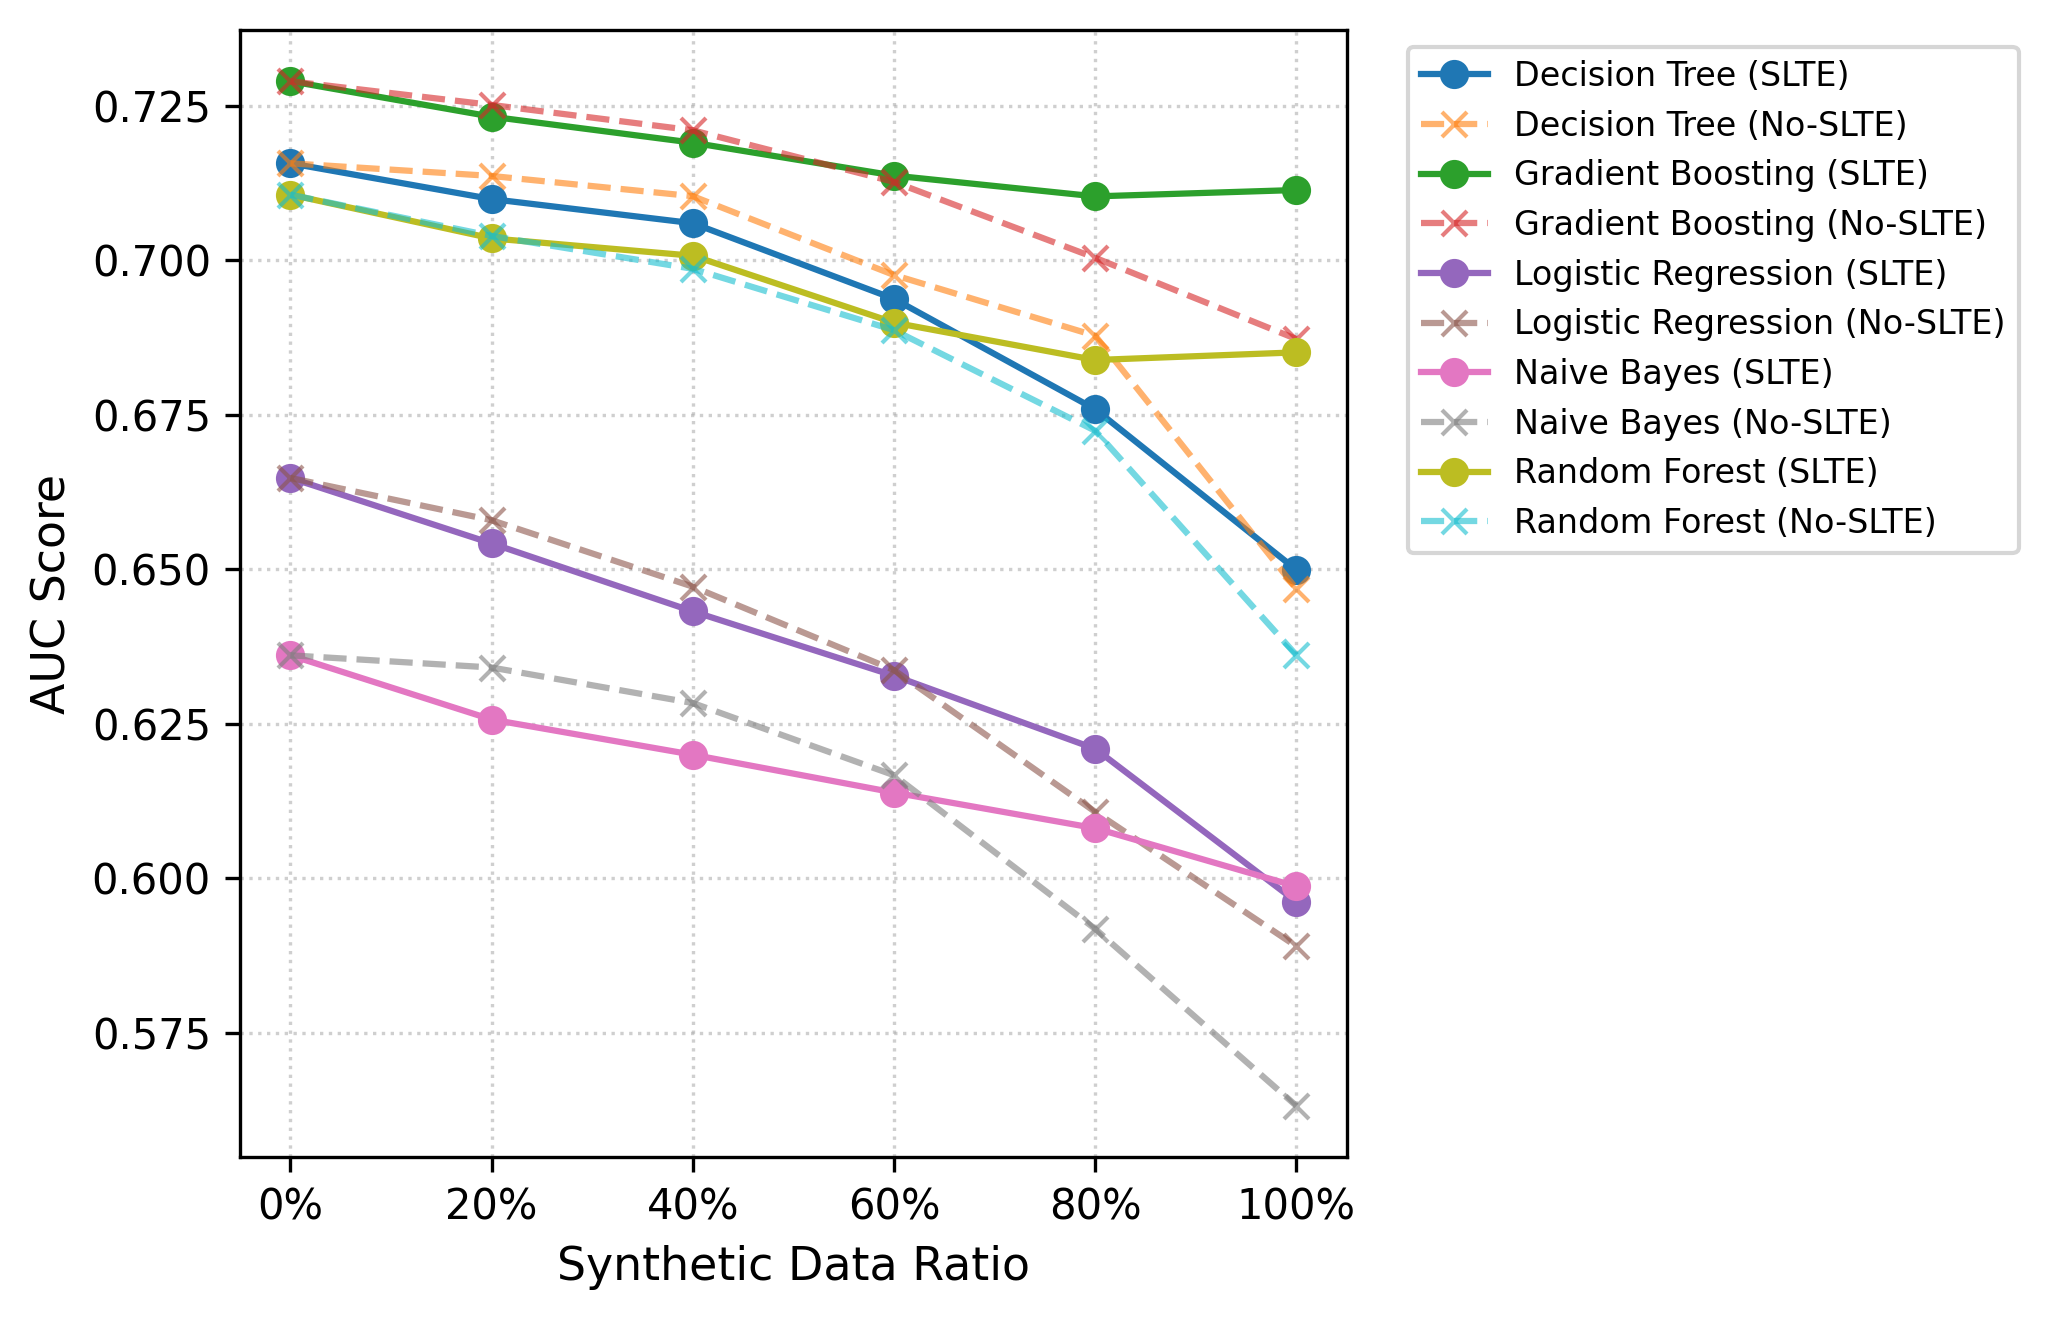

Saved: fig2_auc_ratios.png


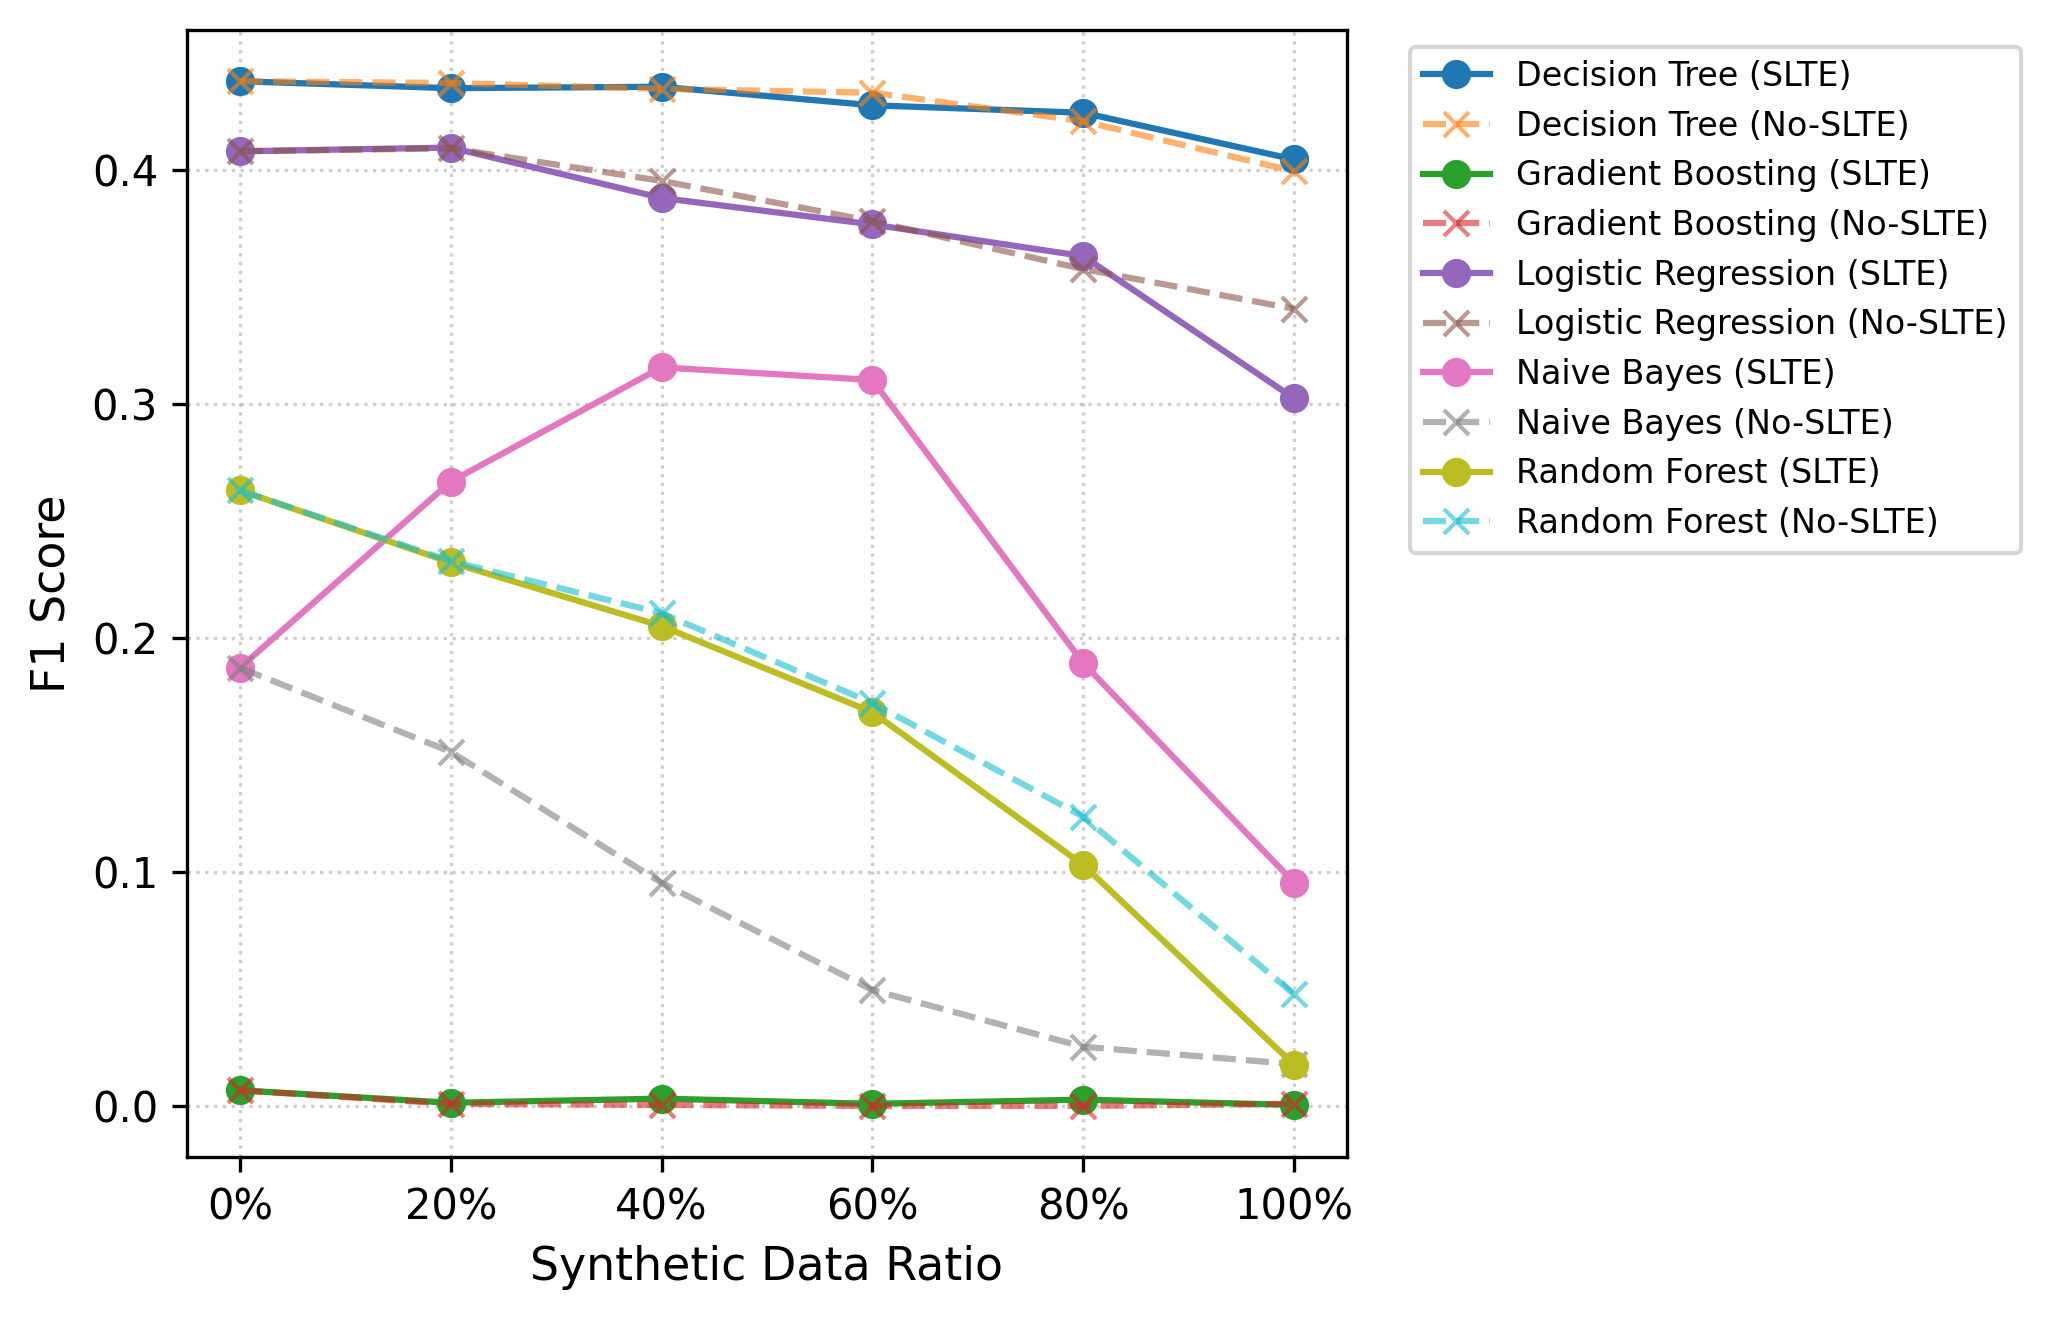

Saved: fig4_f1_ratios.png


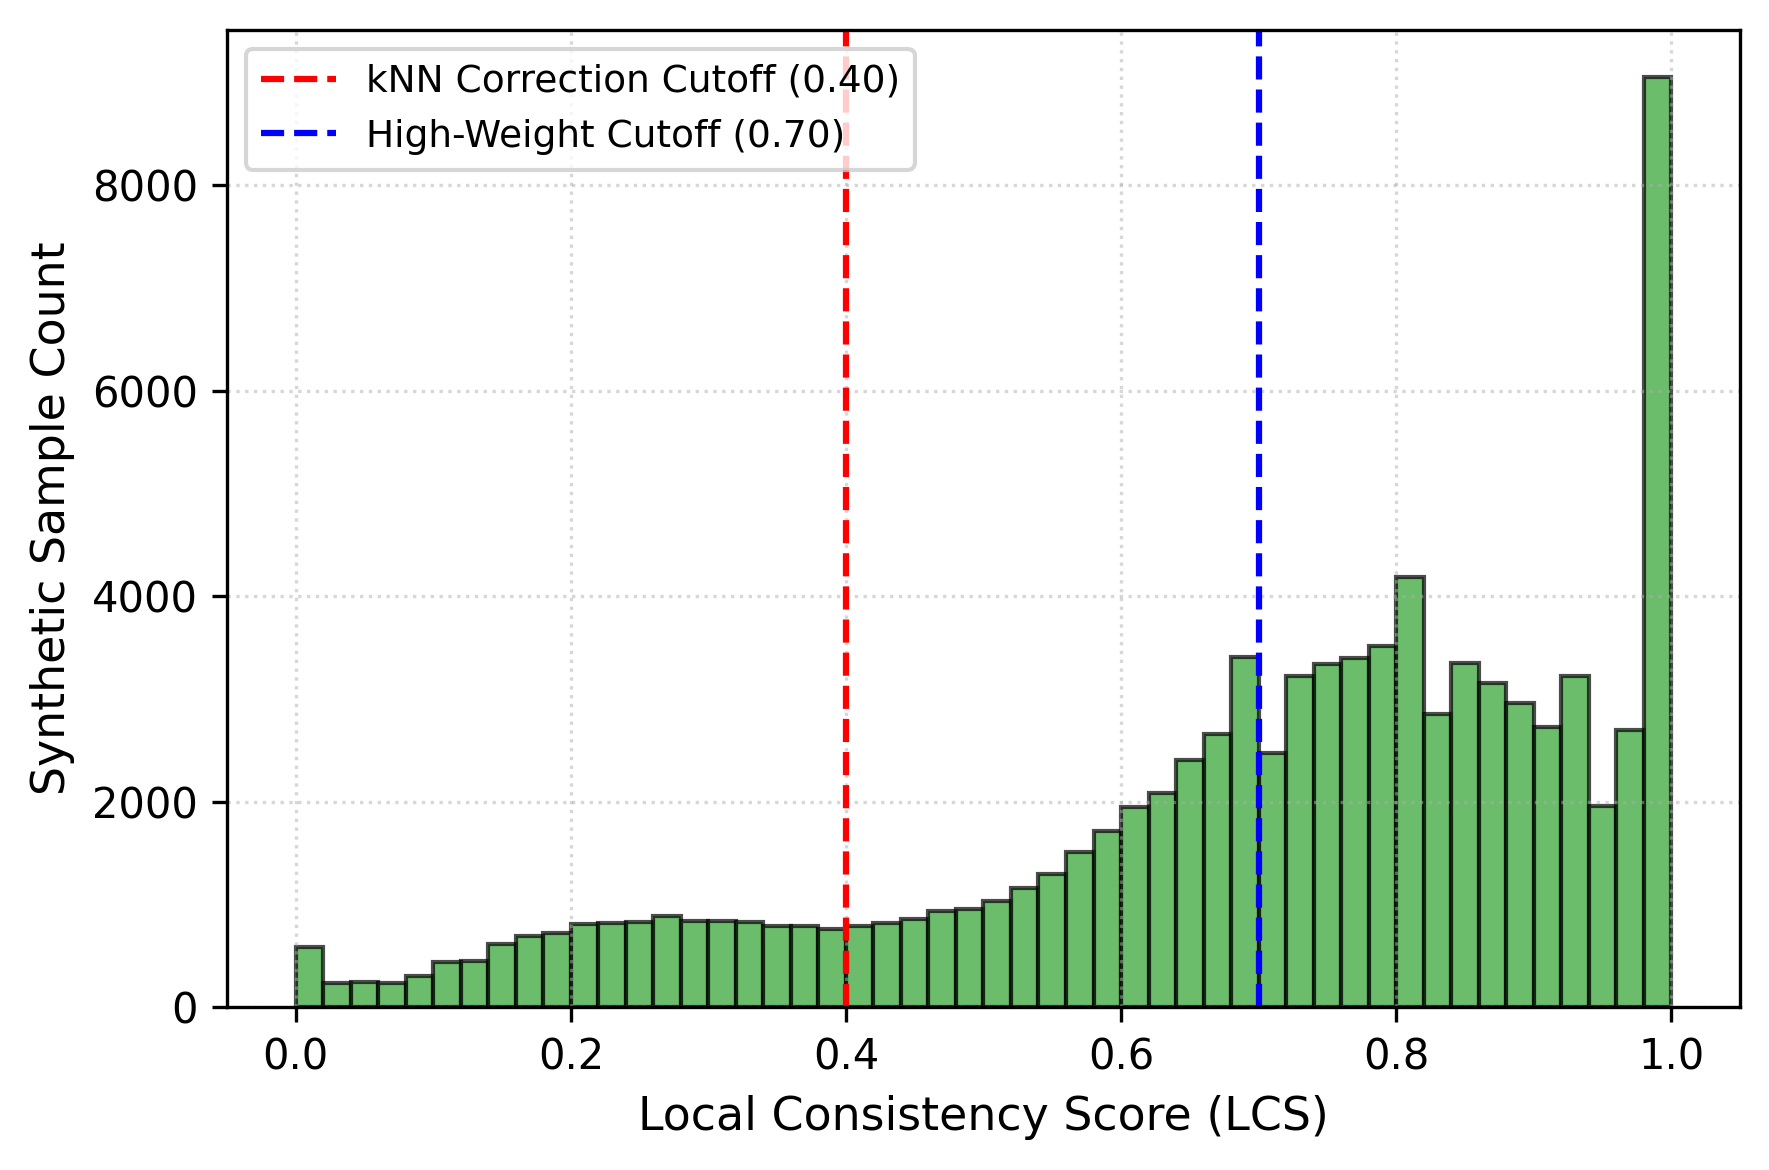

Saved: fig3_lcs_distribution.png


In [26]:
# ============================================================
# TASK 16: RE-EXPORT FIGURES AT 300 DPI WITHOUT TITLES (R2#9)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the full results generated in Cell [15]
df_results = pd.read_csv('slte_all_ratios.csv')

# ------------------------------------------------------------
# FIGURE 2 & 4: AUC & F1 BY RATIO (No-SLTE vs SLTE)
# ------------------------------------------------------------
clfs = ['Decision Tree', 'Gradient Boosting', 'Logistic Regression', 'Naive Bayes', 'Random Forest']
ratios_ordered = ['0%', '20%', '40%', '60%', '80%', '100%']

for metric, fname in [('AUC', 'fig2_auc_ratios.png'), ('F1', 'fig4_f1_ratios.png')]:
    plt.figure(figsize=(7, 4.5), dpi=300)

    for clf in clfs:
        sub_slte = df_results[(df_results['Classifier'] == clf) & (df_results['Mode'] == 'SLTE')]
        sub_slte = sub_slte.set_index('Ratio').loc[ratios_ordered].reset_index()
        plt.plot(sub_slte['Ratio'], sub_slte[metric], marker='o', label=f'{clf} (SLTE)')

        sub_noslte = df_results[(df_results['Classifier'] == clf) & (df_results['Mode'] == 'No-SLTE')]
        sub_noslte = sub_noslte.set_index('Ratio').loc[ratios_ordered].reset_index()
        plt.plot(sub_noslte['Ratio'], sub_noslte[metric], marker='x', linestyle='--', alpha=0.6, label=f'{clf} (No-SLTE)')

    plt.xlabel('Synthetic Data Ratio', fontsize=11)
    plt.ylabel(f'{metric} Score', fontsize=11)
    # NO plt.title(...) line
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# ------------------------------------------------------------
# FIGURE 3: LCS DISTRIBUTION (Stage 1 Confidence Scores)
# ------------------------------------------------------------
plt.figure(figsize=(6, 4), dpi=300)
plt.hist(lcs, bins=50, color='#2ca02c', edgecolor='black', alpha=0.7)
plt.axvline(0.40, color='red', linestyle='--', linewidth=1.5, label='kNN Correction Cutoff (0.40)')
plt.axvline(0.70, color='blue', linestyle='--', linewidth=1.5, label='High-Weight Cutoff (0.70)')
plt.xlabel('Local Consistency Score (LCS)', fontsize=11)
plt.ylabel('Synthetic Sample Count', fontsize=11)
# NO plt.title(...) line
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('fig3_lcs_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3_lcs_distribution.png")

In [27]:
# ============================================================
# TASK 12 -- REFERENCE-SET ABLATION (R2#3)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score

# Sample sizes: 1,000, 5,000, and full (88,420)
N_REFS = [1000, 5000, len(X_train)]
ref_records = []

print("Starting Reference-Set Ablation (Task 12)...")

for n_ref in N_REFS:
    label = "Full (88,420)" if n_ref == len(X_train) else f"{n_ref:,}"
    print(f"\n---> Running n_ref = {label}...")

    # 1. Subsample real reference data
    rs = np.random.RandomState(42)
    idx = rs.choice(len(X_train), n_ref, replace=False)
    X_ref = X_train.iloc[idx]
    y_ref = y_train.iloc[idx]

    # 2. Re-fit Stage 1 & Stage 2 on the smaller reference set
    corr_y_r, w_r, lcs_r = compute_slte_once(X_ref, y_ref, synth_X, synth_y, scale=True)

    n_changed = int((corr_y_r.values != synth_y.values).sum())
    n_1to0 = int(((synth_y.values == 1) & (corr_y_r.values == 0)).sum())
    print(f"     LCS Mean: {lcs_r.mean():.4f} | Corrections: {n_changed} (1->0 flips: {n_1to0})")

    # 3. Fit all 5 classifiers at 100% synthetic data with SLTE corrections
    clfs = make_classifiers(seed=42)
    for name, clf in clfs.items():
        clf.fit(synth_X, corr_y_r, sample_weight=w_r.values)
        proba = clf.predict_proba(X_test)[:, 1]
        pred = clf.predict(X_test)

        auc = roc_auc_score(y_test, proba)
        f1 = f1_score(y_test, pred, zero_division=0)

        ref_records.append({
            'Reference_Size': label,
            'N_Ref': n_ref,
            'Classifier': name,
            'AUC': round(auc, 4),
            'F1': round(f1, 4)
        })

df_ref_ablation = pd.DataFrame(ref_records)
df_ref_ablation.to_csv('reference_set_ablation.csv', index=False)

print("\n" + "="*60)
print("=== TASK 12: REFERENCE-SET ABLATION SUMMARY ===")
print("="*60)
print("\nAUC across Reference Sizes (100% Synthetic + SLTE):")
piv_auc = df_ref_ablation.pivot_table(index='Classifier', columns='Reference_Size', values='AUC')[['1,000', '5,000', 'Full (88,420)']]
print(piv_auc.to_string())

print("\nF1 across Reference Sizes (100% Synthetic + SLTE):")
piv_f1 = df_ref_ablation.pivot_table(index='Classifier', columns='Reference_Size', values='F1')[['1,000', '5,000', 'Full (88,420)']]
print(piv_f1.to_string())

print("\nSaved: reference_set_ablation.csv")

Starting Reference-Set Ablation (Task 12)...

---> Running n_ref = 1,000...
     LCS Mean: 0.7084 | Corrections: 12082 (1->0 flips: 11899)

---> Running n_ref = 5,000...
     LCS Mean: 0.7063 | Corrections: 11796 (1->0 flips: 11449)

---> Running n_ref = Full (88,420)...
     LCS Mean: 0.6983 | Corrections: 11490 (1->0 flips: 10820)

=== TASK 12: REFERENCE-SET ABLATION SUMMARY ===

AUC across Reference Sizes (100% Synthetic + SLTE):
Reference_Size        1,000   5,000  Full (88,420)
Classifier                                        
Decision Tree        0.6055  0.6232         0.6663
Gradient Boosting    0.7000  0.7103         0.7140
Logistic Regression  0.5785  0.5962         0.5939
Naive Bayes          0.5743  0.5921         0.5987
Random Forest        0.6125  0.6507         0.6816

F1 across Reference Sizes (100% Synthetic + SLTE):
Reference_Size        1,000   5,000  Full (88,420)
Classifier                                        
Decision Tree        0.2973  0.3547         0.4063
G

In [28]:
# ============================================================
# TASK 13 -- HELD-OUT kNN VALIDATION (R1#3)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# 1. Split real training set 80/20
X_dev_tr, X_dev_val, y_dev_tr, y_dev_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=42
)

# 2. Scale using the 80% partition
sc = StandardScaler().fit(X_dev_tr)
X_dev_tr_s = pd.DataFrame(sc.transform(X_dev_tr), columns=X_dev_tr.columns, index=X_dev_tr.index)
X_dev_val_s = pd.DataFrame(sc.transform(X_dev_val), columns=X_dev_val.columns, index=X_dev_val.index)

# 3. Fit Anchor (Stage 1) and kNN (Stage 2) on 80% partition
anchor = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42).fit(X_dev_tr_s, y_dev_tr)
knn = KNeighborsClassifier(n_neighbors=7).fit(X_dev_tr_s, y_dev_tr)

# 4. Score 20% validation partition as if labels were unknown
val_proba = anchor.predict_proba(X_dev_val_s)
classes = list(anchor.classes_)
val_lcs = np.array([val_proba[i, classes.index(y_dev_val.iloc[i])] for i in range(len(y_dev_val))])

corrected_val = y_dev_val.values.copy()
low_mask = val_lcs < 0.40
if low_mask.sum() > 0:
    corrected_val[low_mask] = knn.predict(X_dev_val_s[low_mask])

# 5. Measure False Correction Statistics
n_val = len(y_dev_val)
n_changed = int((corrected_val != y_dev_val.values).sum())
n_1to0 = int(((y_dev_val.values == 1) & (corrected_val == 0)).sum())
n_0to1 = int(((y_dev_val.values == 0) & (corrected_val == 1)).sum())
false_correction_rate = (n_changed / n_val) * 100

print("="*60)
print("=== TASK 13: HELD-OUT VALIDATION REPORT ===")
print("="*60)
print(f"Validation records evaluated: {n_val:,}")
print(f"Total false corrections:     {n_changed} ({false_correction_rate:.2f}%)")
print(f"  - Flips 1 -> 0:            {n_1to0} ({n_1to0 / max(n_changed, 1) * 100:.1f}% of changes)")
print(f"  - Flips 0 -> 1:            {n_0to1} ({n_0to1 / max(n_changed, 1) * 100:.1f}% of changes)")
print(f"Mean validation LCS:         {val_lcs.mean():.4f}")
print("Status:", "CREDIBLE (< 15%)" if false_correction_rate < 15 else "HIGH LIMITATION")

=== TASK 13: HELD-OUT VALIDATION REPORT ===
Validation records evaluated: 17,684
Total false corrections:     2511 (14.20%)
  - Flips 1 -> 0:            2280 (90.8% of changes)
  - Flips 0 -> 1:            231 (9.2% of changes)
Mean validation LCS:         0.7222
Status: CREDIBLE (< 15%)


In [29]:
# ============================================================
# TASK 14 -- STAGE 2 vs. STAGE 3 ABLATION AT 100% SYNTHETIC (R2#5)
# ============================================================
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score

arms = {
    'No-SLTE': (synth_y, np.ones(len(synth_y))),
    'Stage 2 Only (kNN Labels)': (corr_y, np.ones(len(synth_y))),
    'Stage 3 Only (Weights)': (synth_y, slte_w.values),
    'Full SLTE (Stage 2 + 3)': (corr_y, slte_w.values)
}

ablation_records = []

for arm_name, (y_target, w_target) in arms.items():
    clfs = make_classifiers(seed=42)
    for clf_name, clf in clfs.items():
        clf.fit(synth_X, y_target, sample_weight=w_target)
        proba = clf.predict_proba(X_test)[:, 1]
        pred = clf.predict(X_test)

        ablation_records.append({
            'Arm': arm_name,
            'Classifier': clf_name,
            'AUC': round(roc_auc_score(y_test, proba), 4),
            'F1': round(f1_score(y_test, pred, zero_division=0), 4)
        })

df_stage_ablation = pd.DataFrame(ablation_records)
df_stage_ablation.to_csv('stage_ablation_results.csv', index=False)

print("\n" + "="*60)
print("=== TASK 14: STAGE ABLATION SUMMARY (100% SYNTHETIC) ===")
print("="*60)
print("\nAUC comparison:")
print(df_stage_ablation.pivot_table(index='Classifier', columns='Arm', values='AUC')[
    ['No-SLTE', 'Stage 2 Only (kNN Labels)', 'Stage 3 Only (Weights)', 'Full SLTE (Stage 2 + 3)']
].to_string())

print("\nF1 comparison:")
print(df_stage_ablation.pivot_table(index='Classifier', columns='Arm', values='F1')[
    ['No-SLTE', 'Stage 2 Only (kNN Labels)', 'Stage 3 Only (Weights)', 'Full SLTE (Stage 2 + 3)']
].to_string())
print("\nSaved: stage_ablation_results.csv")


=== TASK 14: STAGE ABLATION SUMMARY (100% SYNTHETIC) ===

AUC comparison:
Arm                  No-SLTE  Stage 2 Only (kNN Labels)  Stage 3 Only (Weights)  Full SLTE (Stage 2 + 3)
Classifier                                                                                              
Decision Tree         0.6468                     0.6481                  0.6594                   0.6499
Gradient Boosting     0.6873                     0.7095                  0.6978                   0.7114
Logistic Regression   0.5889                     0.5969                  0.5991                   0.5962
Naive Bayes           0.5632                     0.5984                  0.5786                   0.5987
Random Forest         0.6330                     0.6835                  0.6354                   0.6839

F1 comparison:
Arm                  No-SLTE  Stage 2 Only (kNN Labels)  Stage 3 Only (Weights)  Full SLTE (Stage 2 + 3)
Classifier                                                           

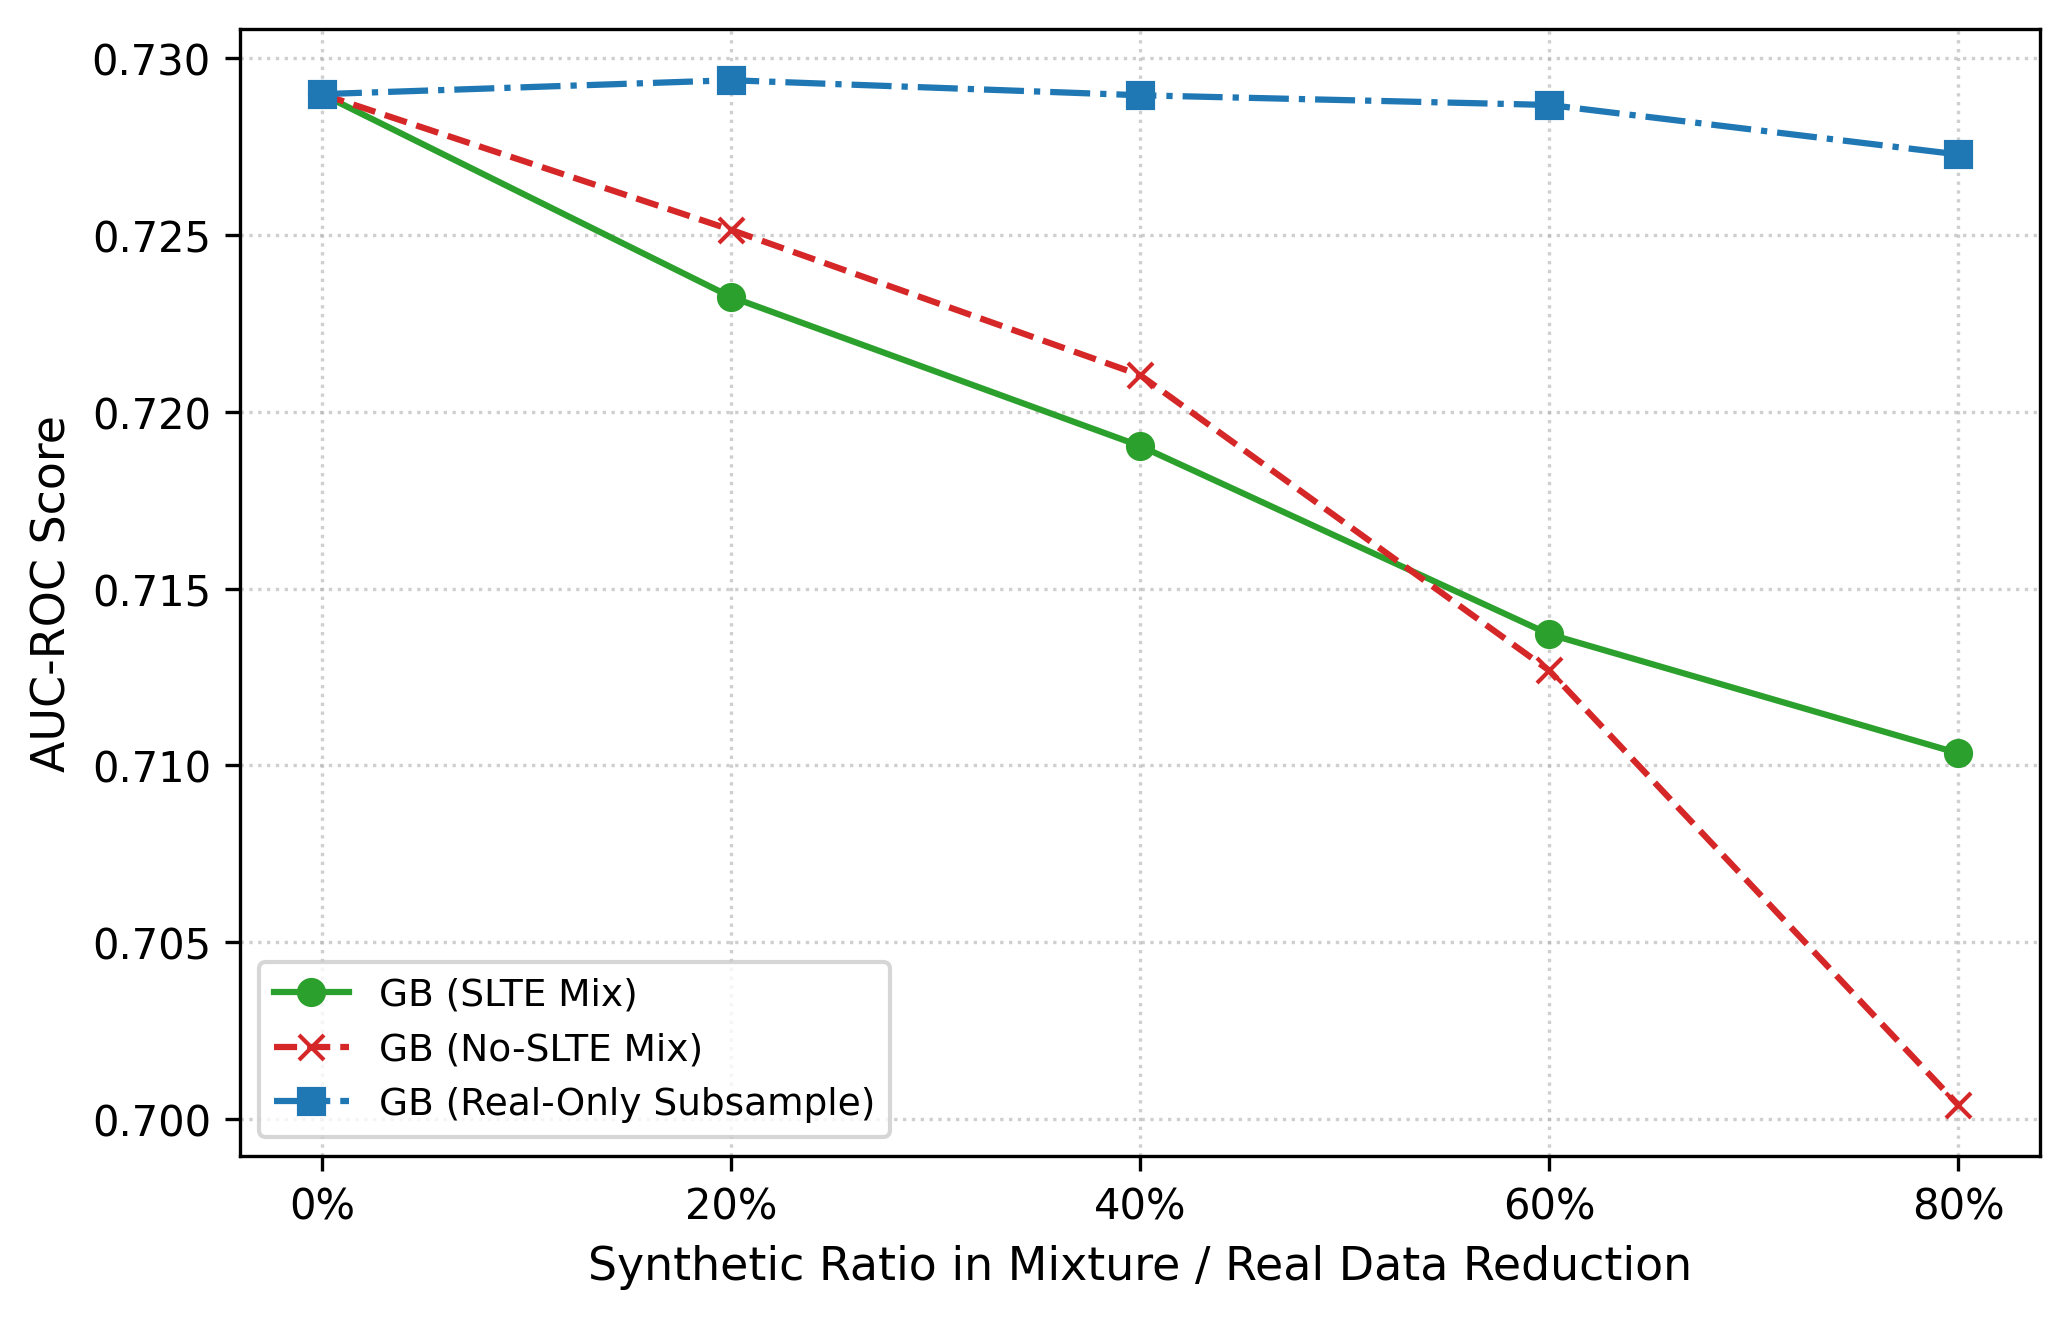

Saved: real_only_learning_curve.csv and fig_gb_real_learning_curve.png


In [30]:
# ============================================================
# TASK 15 -- REAL-ONLY LEARNING CURVE BENCHMARK (R1#6)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

RATIOS = [0.0, 0.2, 0.4, 0.6, 0.8]  # Real-only cannot run at 100% synthetic (0 real rows)
TOTAL_N = len(X_train)
real_records = []

for ratio in RATIOS:
    n_real = TOTAL_N - int(TOTAL_N * ratio)
    rs = np.random.RandomState(42)
    ridx = rs.choice(len(X_train), n_real, replace=False)

    X_sub = X_train.iloc[ridx]
    y_sub = y_train.iloc[ridx]

    clfs = make_classifiers(seed=42)
    for name, clf in clfs.items():
        clf.fit(X_sub, y_sub)
        proba = clf.predict_proba(X_test)[:, 1]
        pred = clf.predict(X_test)

        real_records.append({
            'Ratio': f"{int(ratio * 100)}%",
            'Real_N': n_real,
            'Classifier': name,
            'AUC': roc_auc_score(y_test, proba),
            'F1': f1_score(y_test, pred, zero_division=0)
        })

df_real_only = pd.DataFrame(real_records)
df_real_only.to_csv('real_only_learning_curve.csv', index=False)

# Overlay on Gradient Boosting comparison plot
plt.figure(figsize=(7, 4.5), dpi=300)
df_all = pd.read_csv('slte_all_ratios.csv')
gb_slte = df_all.query("Classifier == 'Gradient Boosting' and Mode == 'SLTE'").set_index('Ratio').loc[['0%', '20%', '40%', '60%', '80%']]
gb_noslte = df_all.query("Classifier == 'Gradient Boosting' and Mode == 'No-SLTE'").set_index('Ratio').loc[['0%', '20%', '40%', '60%', '80%']]
gb_real = df_real_only.query("Classifier == 'Gradient Boosting'").set_index('Ratio').loc[['0%', '20%', '40%', '60%', '80%']]

plt.plot(gb_slte.index, gb_slte['AUC'], marker='o', color='#2ca02c', label='GB (SLTE Mix)')
plt.plot(gb_noslte.index, gb_noslte['AUC'], marker='x', linestyle='--', color='#d62728', label='GB (No-SLTE Mix)')
plt.plot(gb_real.index, gb_real['AUC'], marker='s', linestyle='-.', color='#1f77b4', label='GB (Real-Only Subsample)')

plt.xlabel('Synthetic Ratio in Mixture / Real Data Reduction', fontsize=11)
plt.ylabel('AUC-ROC Score', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_gb_real_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: real_only_learning_curve.csv and fig_gb_real_learning_curve.png")

In [31]:
# ============================================================
# TASK 17 -- DCR PRIVACY PRESERVATION METRIC (R2#6)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# 1. Scale feature space
scaler = StandardScaler().fit(X_train)
X_tr_scaled = scaler.transform(X_train)
synth_X_scaled = scaler.transform(synth_X)

# Subsample 5,000 points to avoid memory overhead
rs = np.random.RandomState(42)
s_idx = rs.choice(len(synth_X), 5000, replace=False)
r_idx = rs.choice(len(X_train), 5000, replace=False)

synth_sample = synth_X_scaled[s_idx]
real_sample = X_tr_scaled[r_idx]

# 2. Fit Nearest Neighbors on the entire real training population
nn = NearestNeighbors(n_neighbors=2, algorithm='ball_tree', n_jobs=-1)
nn.fit(X_tr_scaled)

# 3. Compute DCR (Synthetic to Real)
dcr_synth_to_real, _ = nn.kneighbors(synth_sample, n_neighbors=1)
dcr_synth_to_real = dcr_synth_to_real.ravel()

# 4. Compute Baseline DCR (Real to Real) - neighbor index 1 excludes the self-match
dcr_real_to_real, _ = nn.kneighbors(real_sample, n_neighbors=2)
dcr_real_to_real = dcr_real_to_real[:, 1]

# 5. Summary metrics
dcr_summary = pd.DataFrame({
    'Metric': ['Minimum DCR', '5th Percentile', 'Median DCR', 'Mean DCR'],
    'Synthetic-to-Real': [
        dcr_synth_to_real.min(),
        np.percentile(dcr_synth_to_real, 5),
        np.median(dcr_synth_to_real),
        dcr_synth_to_real.mean()
    ],
    'Real-to-Real (Baseline)': [
        dcr_real_to_real.min(),
        np.percentile(dcr_real_to_real, 5),
        np.median(dcr_real_to_real),
        dcr_real_to_real.mean()
    ]
})

print("\n" + "="*60)
print("=== TASK 17: DCR PRIVACY METRIC REPORT ===")
print("="*60)
print(dcr_summary.to_string(index=False))
print("\nExact 0.0 matches (identity copies):", int((dcr_synth_to_real == 0.0).sum()))
dcr_summary.to_csv('dcr_privacy_results.csv', index=False)
print("Saved: dcr_privacy_results.csv")


=== TASK 17: DCR PRIVACY METRIC REPORT ===
        Metric  Synthetic-to-Real  Real-to-Real (Baseline)
   Minimum DCR           0.000191                 0.000000
5th Percentile           0.036426                 0.000000
    Median DCR           0.246232                 0.068401
      Mean DCR           0.406024                 0.172770

Exact 0.0 matches (identity copies): 0
Saved: dcr_privacy_results.csv


In [32]:
# ============================================================
# TASK 18 -- LOGISTIC REGRESSION CONVERGENCE CHECK (R1#4)
# ============================================================
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('error', category=ConvergenceWarning)

try:
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(synth_X, corr_y, sample_weight=slte_w.values)
    print("Logistic Regression converged cleanly with zero warnings.")
except ConvergenceWarning:
    print("Warning: Logistic Regression failed to converge.")

Logistic Regression converged cleanly with zero warnings.
